# **📊 2.3.3. Các kỹ thuật tiền xử lý và phân tích tác động**

In [1]:
import re, warnings, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords as nltk_sw

import spacy

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import os

output_dir = "../data/images/preprocessing_text"
os.makedirs(output_dir, exist_ok=True)

pd.set_option('display.max_colwidth', None)

# Load dữ liệu
df = pd.read_csv("../data/raw/IMDB Dataset.csv")          # cột: review, sentiment
# Đánh nhãn
df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print("Shape:", df.shape)
print(df['sentiment'].value_counts())

df.head(5)

Shape: (50000, 3)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment,label
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive,1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive,1
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and 

## **📌 a) Pipeline chuẩn hóa văn bản**

---

### **🎯 Mục tiêu**

Mục tiêu của bước chuẩn hóa văn bản là làm sạch dữ liệu đầu vào nhằm:
- 🧹 Loại bỏ nhiễu (HTML, URL, ký tự đặc biệt, ...)
- 🔤 Chuẩn hóa định dạng văn bản
- 📉 Giảm kích thước từ vựng (vocabulary size)
- ⚖️ Ổn định độ dài văn bản

---

### **⚙️ Phương pháp**

Pipeline chuẩn hóa được thực hiện tuần tự qua các bước sau:

#### **🔹 1. Lowercase**
Chuyển toàn bộ văn bản về chữ thường nhằm tránh trùng lặp từ vựng do khác biệt hoa/thường.

#### **🔹 2. Loại bỏ HTML tags**
Sử dụng biểu thức chính quy để loại bỏ các thẻ HTML:
- Ví dụ: `<br>`, `<div>`, ...

#### **🔹 3. Loại bỏ URL**
Xóa các đường dẫn web:
- Ví dụ: `http://...`, `https://...`, `www...`

#### **🔹 4. Loại bỏ mention và hashtag**
Loại bỏ các thành phần thường gặp trong mạng xã hội:
- `@username`
- `#hashtag`

#### **🔹 5. Loại bỏ ký tự đặc biệt và số**
Chỉ giữ lại:
- Chữ cái (a–z)
- Dấu nháy `'`
- Khoảng trắng  

Các ký tự khác sẽ bị loại bỏ để giảm nhiễu.

#### **🔹 6. Chuẩn hóa khoảng trắng**
- Đảm bảo mỗi từ cách nhau đúng một khoảng trắng  

---

### **📏 Chỉ số đánh giá**

Để đánh giá tác động của từng bước, sử dụng hai chỉ số:

#### **🔤 Vocabulary Size**
Số lượng từ khác nhau trong tập dữ liệu:

$$
\text{Vocab Size} = |\text{Unique Tokens}|
$$

#### **🔢 Độ dài văn bản trung bình**

Số từ trung bình trên mỗi văn bản:

$$
\text{Avg Length} = \frac{\sum \text{số từ}}{\text{số văn bản}}
$$

---

### **📊 Theo dõi sự thay đổi**

Sau mỗi bước, các chỉ số được ghi lại:

- 📉 **∆Vocab (%)**: phần trăm thay đổi kích thước từ vựng  
- 📏 **∆AvgLen (%)**: phần trăm thay đổi độ dài trung bình  
---

### **📈 Trực quan hóa**

Hai biểu đồ được sử dụng:

- 📊 **Biểu đồ Vocabulary Size**: so sánh trước và sau mỗi bước  
- 📊 **Biểu đồ Avg Text Length**: theo dõi độ dài văn bản  


a) PIPELINE CHUẨN HÓA VĂN BẢN
  1. Lowercase                        vocab: 390,931 → 390,931  (-0.0%)  avgLen: 231.2 → 231.2  (-0.0%)
  2. Remove HTML tags                 vocab: 390,931 → 365,396  (-6.5%)  avgLen: 231.2 → 228.9  (-1.0%)
  3. Remove URLs                      vocab: 365,396 → 365,226  (-0.0%)  avgLen: 228.9 → 228.9  (-0.0%)
  4. Remove @mention / #hashtag       vocab: 365,226 → 365,103  (-0.0%)  avgLen: 228.9 → 228.9  (-0.0%)
  5. Remove special chars (keep punctuation) vocab: 365,103 → 232,098  (-36.4%)  avgLen: 228.9 → 231.3  (+1.1%)
  6. Normalize whitespace             vocab: 232,098 → 232,098  (-0.0%)  avgLen: 231.3 → 231.3  (-0.0%)

=== Bảng tổng kết các bước chuẩn hóa ===
                                      Bước  Vocab trước  Vocab sau  ∆Vocab (%)  AvgLen trước  AvgLen sau  ∆AvgLen (%)
                              1. Lowercase       390931     390931       -0.00         231.2       231.2        -0.00
                       2. Remove HTML tags       390931    

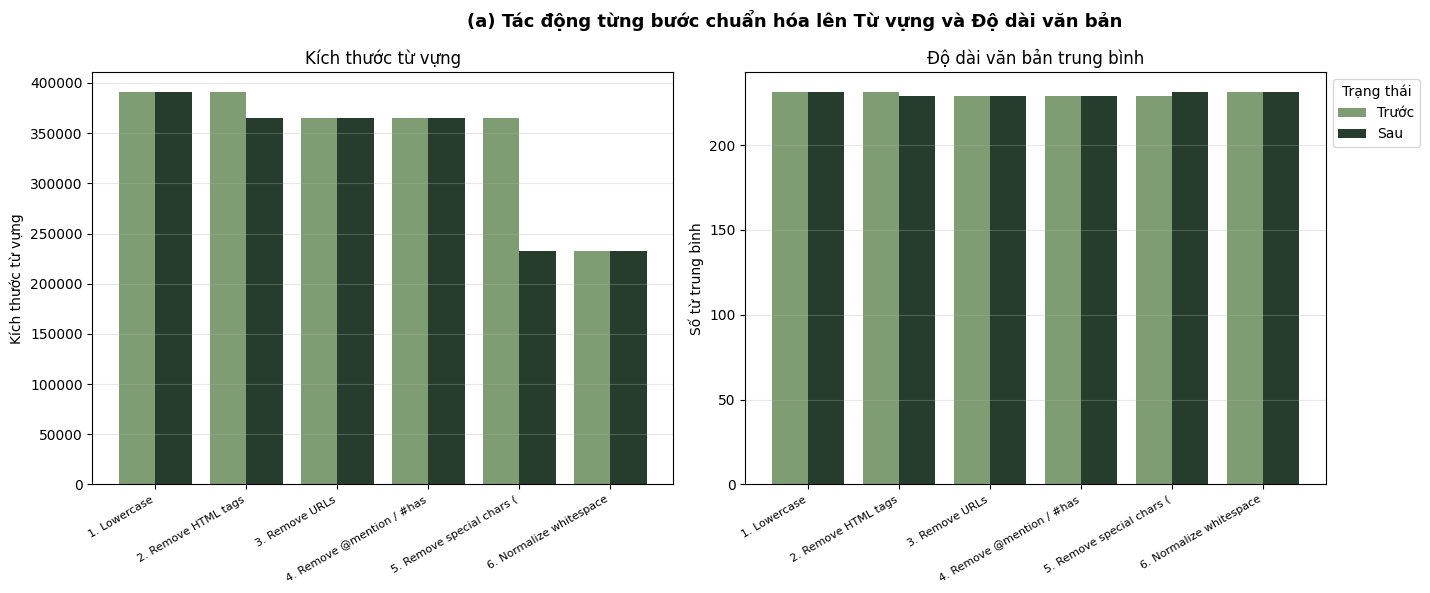

In [2]:
# a) PIPELINE CHUẨN HÓA VĂN BẢN
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("a) PIPELINE CHUẨN HÓA VĂN BẢN")
print("="*65)

raw = df['review'].copy()

def vocab_size(series):
    tokens = series.str.lower().str.split().explode()
    return tokens.nunique()

def avg_len(series):
    return series.str.split().apply(len).mean()

steps_log = []

def log_step(name, before, after):
    v_before = vocab_size(before)
    v_after  = vocab_size(after)
    l_before = avg_len(before)
    l_after  = avg_len(after)
    vocab_change = (v_before - v_after) / v_before * 100
    len_change   = (l_before - l_after) / l_before * 100
    steps_log.append({
        'Bước': name,
        'Vocab trước': v_before,
        'Vocab sau': v_after,
        '∆Vocab (%)': round(-vocab_change, 2),
        'AvgLen trước': round(l_before, 1),
        'AvgLen sau': round(l_after, 1),
        '∆AvgLen (%)': round(-len_change, 2),
    })
    print(f"  {name:<35} vocab: {v_before:>7,} → {v_after:>7,}  ({-vocab_change:+.1f}%)  "
          f"avgLen: {l_before:.1f} → {l_after:.1f}  ({-len_change:+.1f}%)")

# ── Bước 1: Lowercase ────────────────────────────────────────────────
s1 = raw.str.lower()
log_step("1. Lowercase", raw, s1)

# ── Bước 2: Loại HTML ────────────────────────────────────────────────
s2 = s1.apply(lambda x: re.sub(r'<[^>]+>', ' ', x))
log_step("2. Remove HTML tags", s1, s2)

# ── Bước 3: Loại URL ─────────────────────────────────────────────────
s3 = s2.apply(lambda x: re.sub(r'https?://\S+|www\.\S+', ' ', x))
log_step("3. Remove URLs", s2, s3)

# ── Bước 4: Loại mention & hashtag ──────────────────────────────────
s4 = s3.apply(lambda x: re.sub(r'@\w+|#\w+', ' ', x))
log_step("4. Remove @mention / #hashtag", s3, s4)

# ── Bước 5: Loại ký tự đặc biệt (giữ chữ cái + khoảng trắng) ────────
s5 = s4.apply(lambda x: re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\']", ' ', x))
log_step("5. Remove special chars (keep punctuation)", s4, s5)

# ── Bước 6: Chuẩn hóa khoảng trắng ──────────────────────────────────
s6 = s5.apply(lambda x: re.sub(r'\s+', ' ', x).strip())
log_step("6. Normalize whitespace", s5, s6)

df['text_norm'] = s6

# ── Báo cáo bảng ─────────────────────────────────────────────────────
steps_df = pd.DataFrame(steps_log)
print("\n=== Bảng tổng kết các bước chuẩn hóa ===")
print(steps_df.to_string(index=False))
# steps_df.to_csv("{output_dir}/preproc_a_steps.csv", index=False)

# ── Biểu đồ tác động ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  
fig.suptitle("(a) Tác động từng bước chuẩn hóa lên Từ vựng và Độ dài văn bản", fontsize=13, fontweight='bold')

x = range(len(steps_df))
labels = [s[:25] for s in steps_df['Bước']]

# Biểu đồ 1: Vocab Size
ax0 = axes[0]
ax0.bar(x, steps_df['Vocab trước'], width=0.4, label='Trước', color='#7e9d73', align='center')
ax0.bar([i+0.4 for i in x], steps_df['Vocab sau'], width=0.4, label='Sau', color='#263d2d', align='center')
ax0.set_xticks([i+0.2 for i in x]); ax0.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax0.set_ylabel('Kích thước từ vựng'); ax0.set_title('Kích thước từ vựng'); ax0.grid(axis='y', alpha=0.3)

# Biểu đồ 2: Avg Length
ax1 = axes[1]
ax1.bar(x, steps_df['AvgLen trước'], width=0.4, label='Trước', color="#7e9d73", align='center')
ax1.bar([i+0.4 for i in x], steps_df['AvgLen sau'], width=0.4, label='Sau', color='#263d2d', align='center')
ax1.set_xticks([i+0.2 for i in x]); ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Số từ trung bình'); ax1.set_title('Độ dài văn bản trung bình'); ax1.grid(axis='y', alpha=0.3)

# Đặt Legend ra bên ngoài phía bên phải của biểu đồ thứ 2
loc='upper left'
bbox_to_anchor=(1, 1)
ax1.legend(title="Trạng thái", loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=0.5)

plt.tight_layout(rect=[0, 0, 0.9, 1]) 

# Lưu trữ  
steps_df.to_csv(f"{output_dir}/a_preproc_a_steps.csv", index=False)
plt.savefig(f"{output_dir}/a_preproc_a_pipeline_impact.png", dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# Sau khi chuẩn hóa văn bản
df.head(5)

,review,sentiment,label,text_norm
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,1,"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word. it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. i would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. forget pretty pictures painted for mainstream audiences, forget charm, forget romance...oz doesn't mess around. the first episode i ever saw struck me as so nasty it was surreal, i couldn't say i was ready for it, but as i watched more, i developed a taste for oz, and got accustomed to the high levels of graphic violence. not just violence, but injustice crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well wor

## **📌 b) So sánh chiến lược Tokenization**

---

### **🎯 Mục tiêu**

Tokenization là bước chuyển đổi văn bản thành các đơn vị nhỏ hơn (tokens), đóng vai trò quan trọng trong xử lý ngôn ngữ tự nhiên.

Mục tiêu của phần này:
- 🔍 So sánh các chiến lược tokenization khác nhau  
- 📊 Đánh giá ảnh hưởng đến từ vựng và biểu diễn văn bản  
- ⚖️ Lựa chọn phương pháp phù hợp cho mô hình  

---

### **⚙️ Phương pháp**

Thực nghiệm được thực hiện trên tập mẫu 5,000 văn bản, chia thành:
- 📚 **Train set**: 4,000 mẫu  
- 🧪 **Test set**: 1,000 mẫu  

**Các chiến lược tokenization được so sánh:**

#### **🔹 1. Word-level (NLTK)**

- Tách văn bản thành các từ riêng lẻ bằng thư viện NLTK  
- Đơn giản, dễ hiểu, phổ biến  

#### **🔹 2. Word-level (spaCy)**

- Sử dụng tokenizer của spaCy  
- Xử lý tốt hơn các trường hợp phức tạp (dấu câu, từ ghép, ...)

#### **🔹 3. Sentence-level**

- Chia văn bản thành các câu  
- Token = một câu hoàn chỉnh  

#### **🔹 4. Subword-level (BPE)**

- Sử dụng Byte Pair Encoding (BPE) để tách từ thành các đơn vị nhỏ hơn  
- Được huấn luyện trên tập train  

#### **🔹 5. Character-level (bonus)**

- Mỗi ký tự là một token  

---

### **📏 Chỉ số đánh giá**

Các chiến lược được so sánh dựa trên các tiêu chí:
#### **🔤 Vocabulary Size**

Số lượng token khác nhau trong tập train:

$$
\text{Vocab Size} = |\text{Unique Tokens}|
$$

#### **⚠️ OOV Ratio (Out-Of-Vocabulary)**

Tỷ lệ token trong tập test không xuất hiện trong tập train:

$$
\text{OOV Ratio} = \frac{\text{số token không có trong vocab}}{\text{tổng số token}}
$$

- OOV thấp → mô hình tổng quát tốt hơn  
- OOV cao → nhiều từ mới không được học  

#### **📏 Average Sequence Length**

Độ dài trung bình của mỗi chuỗi token:

$$
\text{Avg Length} = \frac{\sum \text{số token}}{\text{số văn bản}}
$$

#### **⏱️ Processing Time**

Thời gian xử lý trên 5,000 mẫu:

- Đánh giá hiệu suất của từng phương pháp  

---

### **📊 Trực quan hóa**

Ba biểu đồ được sử dụng để so sánh:

- 📊 **Vocabulary Size**  
- 📊 **OOV Ratio (%)**  
- 📊 **Average Sequence Length**  


b) SO SÁNH CHIẾN LƯỢC TOKENIZATION
  [1/4] NLTK word tokenizer ...
  [2/4] spaCy word tokenizer ...
  [3/4] Sentence tokenizer ...
  [4/4] BPE subword tokenizer (training) ...
  [+] Character-level ...

=== Bảng so sánh chiến lược tokenization ===
      Strategy  Vocab size  OOV ratio  Avg seq len  Time (s/5k)
     Word-NLTK       37228      1.885        261.6        10.35
    Word-spaCy       36508      1.825        262.1       199.69
Sentence-level       48226     97.312         12.2         0.79
   Subword-BPE        7879      0.004        296.1         5.21
    Char-level          42      0.000       1291.1         0.00
Đã lưu: b_tokenization.png (Grid 2x2)
Đã lưu: b_tokenization.csv


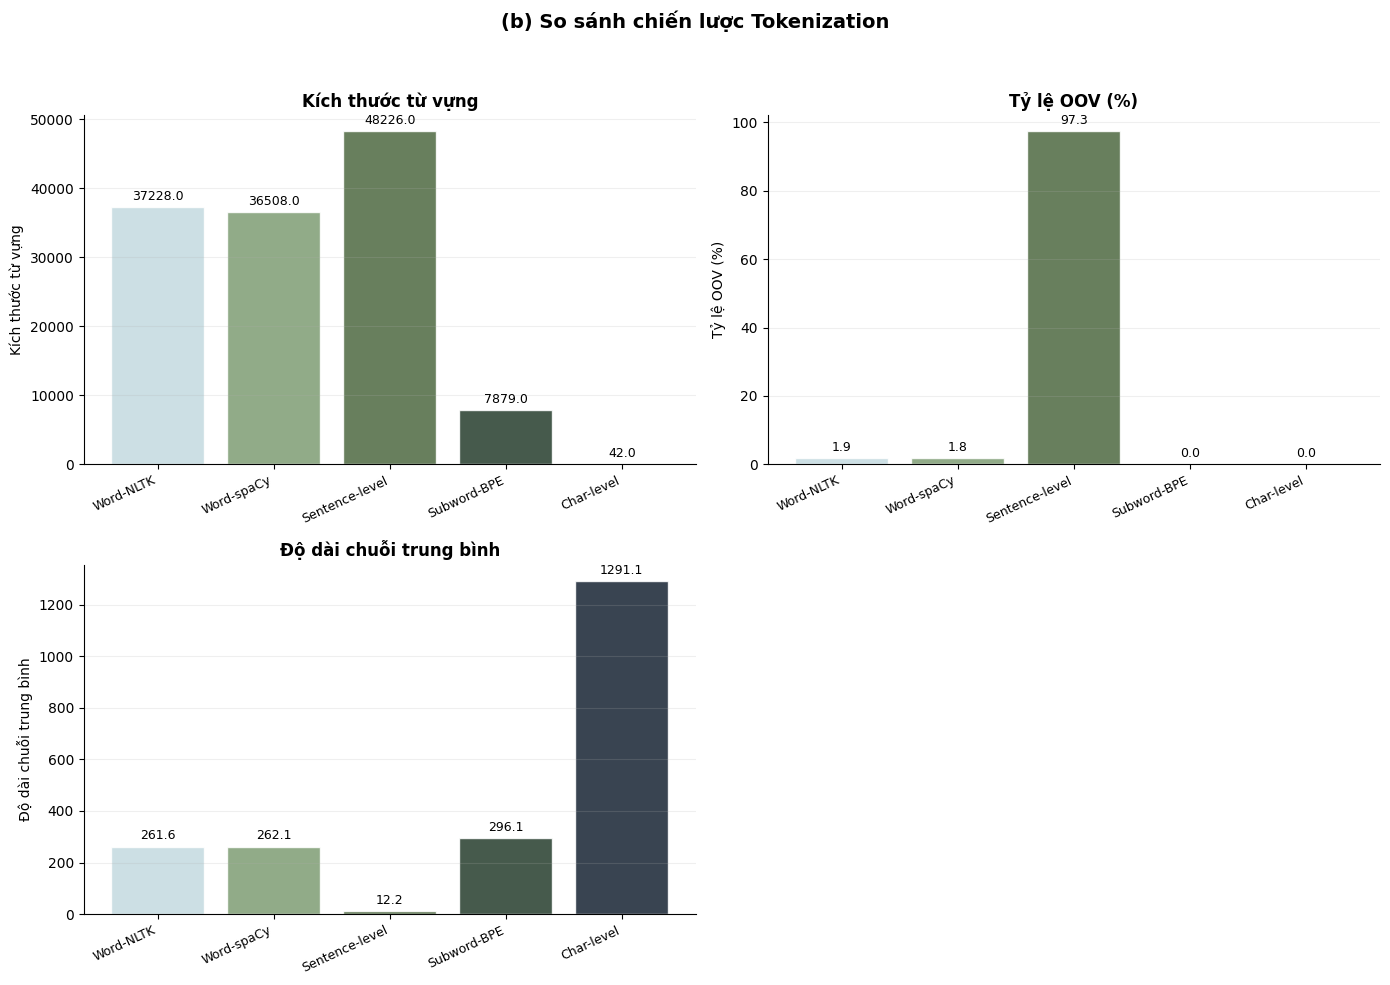

In [4]:
# b) SO SÁNH CHIẾN LƯỢC TOKENIZATION
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("b) SO SÁNH CHIẾN LƯỢC TOKENIZATION")
print("="*65)

SAMPLE = 5000
texts = df['text_norm'].sample(SAMPLE, random_state=42).tolist()
train_texts, test_texts = texts[:4000], texts[4000:]

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

tok_results = []

# ── 1. Word-level – NLTK ─────────────────────────────────────────────
print("  [1/4] NLTK word tokenizer ...")
t0 = time.time()
nltk_tokens = [word_tokenize(t) for t in texts]
t_nltk = time.time() - t0
train_nltk  = [word_tokenize(t) for t in train_texts]
test_nltk   = [word_tokenize(t) for t in test_texts]
vocab_nltk  = set(tok for s in train_nltk for tok in s)
oov_nltk    = sum(1 for s in test_nltk for tok in s if tok not in vocab_nltk) / \
              max(sum(len(s) for s in test_nltk), 1)
tok_results.append({
    'Strategy': 'Word-NLTK',
    'Vocab size': len(vocab_nltk),
    'OOV ratio': round(oov_nltk*100, 3),
    'Avg seq len': round(np.mean([len(s) for s in nltk_tokens]), 1),
    'Time (s/5k)': round(t_nltk, 2),
})

# ── 2. Word-level – spaCy ────────────────────────────────────────────
print("  [2/4] spaCy word tokenizer ...")
t0 = time.time()
spacy_tokens = [[tok.text for tok in doc] for doc in nlp.pipe(texts, batch_size=256)]
t_spacy = time.time() - t0
train_spacy = [[tok.text for tok in doc] for doc in nlp.pipe(train_texts, batch_size=256)]
test_spacy  = [[tok.text for tok in doc] for doc in nlp.pipe(test_texts, batch_size=256)]
vocab_spacy = set(tok for s in train_spacy for tok in s)
oov_spacy   = sum(1 for s in test_spacy for tok in s if tok not in vocab_spacy) / \
              max(sum(len(s) for s in test_spacy), 1)
tok_results.append({
    'Strategy': 'Word-spaCy',
    'Vocab size': len(vocab_spacy),
    'OOV ratio': round(oov_spacy*100, 3),
    'Avg seq len': round(np.mean([len(s) for s in spacy_tokens]), 1),
    'Time (s/5k)': round(t_spacy, 2),
})

# ── 3. Sentence-level ────────────────────────────────────────────────
print("  [3/4] Sentence tokenizer ...")
t0 = time.time()
sent_tokens = [sent_tokenize(t) for t in texts]
t_sent = time.time() - t0
# Vocab = tập câu duy nhất (ít ý nghĩa, nhưng báo cáo số câu trung bình)
unique_sents_train = set(s for doc in [sent_tokenize(t) for t in train_texts] for s in doc)
unique_sents_test  = [s for doc in [sent_tokenize(t) for t in test_texts]  for s in doc]
oov_sent = sum(1 for s in unique_sents_test if s not in unique_sents_train) / max(len(unique_sents_test), 1)
tok_results.append({
    'Strategy': 'Sentence-level',
    'Vocab size': len(unique_sents_train),
    'OOV ratio': round(oov_sent*100, 3),
    'Avg seq len': round(np.mean([len(s) for s in sent_tokens]), 1),
    'Time (s/5k)': round(t_sent, 2),
})

# ── 4. Subword – BPE (HuggingFace tokenizers) ───────────────────────
print("  [4/4] BPE subword tokenizer (training) ...")
t0 = time.time()
tokenizer_bpe = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer_bpe.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=8000, min_frequency=2,
                     special_tokens=["[UNK]", "[PAD]"])
tokenizer_bpe.train_from_iterator(train_texts, trainer=trainer)
bpe_train_tokens = [tokenizer_bpe.encode(t).tokens for t in train_texts]
bpe_test_tokens  = [tokenizer_bpe.encode(t).tokens for t in test_texts]
bpe_all_tokens   = [tokenizer_bpe.encode(t).tokens for t in texts]
t_bpe = time.time() - t0
vocab_bpe = set(tok for s in bpe_train_tokens for tok in s)
oov_bpe   = sum(1 for s in bpe_test_tokens for tok in s if tok not in vocab_bpe) / \
            max(sum(len(s) for s in bpe_test_tokens), 1)
tok_results.append({
    'Strategy': 'Subword-BPE',
    'Vocab size': len(vocab_bpe),
    'OOV ratio': round(oov_bpe*100, 3),
    'Avg seq len': round(np.mean([len(s) for s in bpe_all_tokens]), 1),
    'Time (s/5k)': round(t_bpe, 2),
})

# Char-level (bonus)
print("  [+] Character-level ...")
char_tokens = [list(t) for t in texts]
train_char  = [list(t) for t in train_texts]
test_char   = [list(t) for t in test_texts]
vocab_char  = set(c for s in train_char for c in s)
oov_char    = sum(1 for s in test_char for c in s if c not in vocab_char) / \
              max(sum(len(s) for s in test_char), 1)
tok_results.append({
    'Strategy': 'Char-level',
    'Vocab size': len(vocab_char),
    'OOV ratio': round(oov_char*100, 3),
    'Avg seq len': round(np.mean([len(s) for s in char_tokens]), 1),
    'Time (s/5k)': 0.0,
})

tok_df = pd.DataFrame(tok_results)
print("\n=== Bảng so sánh chiến lược tokenization ===")
print(tok_df.to_string(index=False))
#tok_df.to_csv("preproc_b_tokenization.csv", index=False)

# ── Visualize ────────────────────────────────────────────────────────
# Tạo lưới 2 hàng, 2 cột
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("(b) So sánh chiến lược Tokenization", fontsize=14, fontweight='bold')

colors = ['#c3dae0','#7e9d73','#4d6940','#263d2d','#162333']
metrics = ['Vocab size', 'OOV ratio', 'Avg seq len']
titles = ['Kích thước từ vựng', 'Tỷ lệ OOV (%)', 'Độ dài chuỗi trung bình']

# Trải phẳng axes để dễ dàng lặp qua 3 ô đầu
axes_flat = axes.flatten()

for i, (col, title) in enumerate(zip(metrics, titles)):
    ax = axes_flat[i]
    bars = ax.bar(tok_df['Strategy'], tok_df[col], 
                  color=colors, alpha=0.85, edgecolor='white')

    ax.set_title(title, fontsize=12, fontweight='semibold')
    ax.set_ylabel(title)

    # Hiển thị giá trị trên cột
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)

    # Fix label trục x
    ax.set_xticks(range(len(tok_df['Strategy'])))
    ax.set_xticklabels(tok_df['Strategy'], rotation=25, ha='right', fontsize=9)

    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

# ── Xử lý ô thứ 4 (bỏ trống) ────────────────────────────────────────
axes_flat[3].axis('off') 

# Tăng khoảng cách giữa các hàng để không bị đè nhãn
plt.tight_layout(rect=[0, 0, 1, 0.95])

# ── Save ─────────────────────────────────────────────────────────────
tok_df.to_csv(f"{output_dir}/b_tokenization.csv", index=False)
plt.savefig(f"{output_dir}/b_tokenization.png", dpi=150, bbox_inches='tight')

print("Đã lưu: b_tokenization.png (Grid 2x2)")
print("Đã lưu: b_tokenization.csv")

plt.show()

## **📌 c) Stopword Removal + Mutual Information + Naive Bayes**

---

### **🎯 Mục tiêu**

Stopword Removal là bước loại bỏ các từ phổ biến nhưng ít mang ý nghĩa (như: *the, is, and, ...*).

Mục tiêu của phần này:
- 🧹 Đánh giá tác động của việc loại bỏ stopwords  
- 📊 Phân tích ảnh hưởng đến đặc trưng (feature quality) thông qua Mutual Information  
- 🤖 Đánh giá hiệu năng mô hình Naive Bayes trước và sau khi xử lý  

---

### **⚙️ Phương pháp**

Thực nghiệm được thực hiện trên dữ liệu đã qua bước chuẩn hóa (phần a):

- 📚 Chia dữ liệu:
  - **Train set**: 80%  
  - **Test set**: 20% (stratified)  

- 🧹 Xây dựng 2 phiên bản dữ liệu:
  - **Trước (w/ stopwords)**: giữ nguyên văn bản  
  - **Sau (w/o stopwords)**: loại bỏ stopwords  

---

### **🔄 Các bước thực hiện**

#### **1. Stopword Removal**

- Loại bỏ các từ nằm trong danh sách stopwords tiếng Anh (NLTK)

#### **2. Vector hóa (Bag-of-Words)**

Sử dụng CountVectorizer:

- Giới hạn:
  - `max_features = 20000`  
  - `min_df = 2`  

📌 Kết quả:
- Biểu diễn văn bản dưới dạng vector tần suất từ  

#### **3. Mutual Information (MI)**

Đo mức độ liên quan giữa từng đặc trưng (từ) và nhãn:

$$
MI(X, Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}
$$

📌 Ý nghĩa:
- MI cao → từ có khả năng phân biệt lớp tốt  
- MI thấp → từ ít giá trị  

Trong thực nghiệm:
- Tính MI trên tập train  
- Lấy giá trị trung bình (**Avg MI**)  

#### **4. Naive Bayes (MultinomialNB)**

Áp dụng mô hình Naive Bayes cho phân loại văn bản:

📌 Đánh giá:
- 🔁 **Cross-validation (5-fold)** trên train  
- 🧪 **Test accuracy** trên tập test  

---

### **📏 Chỉ số đánh giá**

#### **🔤 Vocabulary Size**

Số lượng từ trong từ điển:

$$
\text{Vocab Size} = |\text{Vocabulary}|
$$

#### **📊 Average Mutual Information**

Giá trị trung bình MI của các đặc trưng:

- MI cao → đặc trưng tốt hơn  

#### **🤖 Naive Bayes Accuracy**

- **NB CV Acc (%)**: độ chính xác trung bình qua cross-validation  
- **NB Test Acc (%)**: độ chính xác trên tập test  

---

### **📊 Trực quan hóa**

Ba biểu đồ được sử dụng để so sánh:

- 📊 **Vocabulary Size**  
- 📊 **Average Mutual Information**  
- 📊 **Naive Bayes Test Accuracy (%)**  

Giúp:
- So sánh trực quan trước và sau khi loại stopwords  
- Đánh giá trade-off giữa giảm vocab và hiệu năng  


c) STOPWORD REMOVAL + MI + NAIVE BAYES
  Trước (w/ stopwords): vocab=20,000, avgMI=0.000187, CV=84.25%, Test=84.36%
  Sau (w/o stopwords): vocab=20,000, avgMI=0.000178, CV=85.42%, Test=85.72%

=== Bảng so sánh trước/sau loại stopwords ===
          Trạng thái  Vocab size   Avg MI  NB CV Acc (%)  NB Test Acc (%)
Trước (w/ stopwords)       20000 0.000187          84.25            84.36
 Sau (w/o stopwords)       20000 0.000178          85.42            85.72
Đã lưu: c_stopwords.csv
Đã lưu: c_stopwords.png


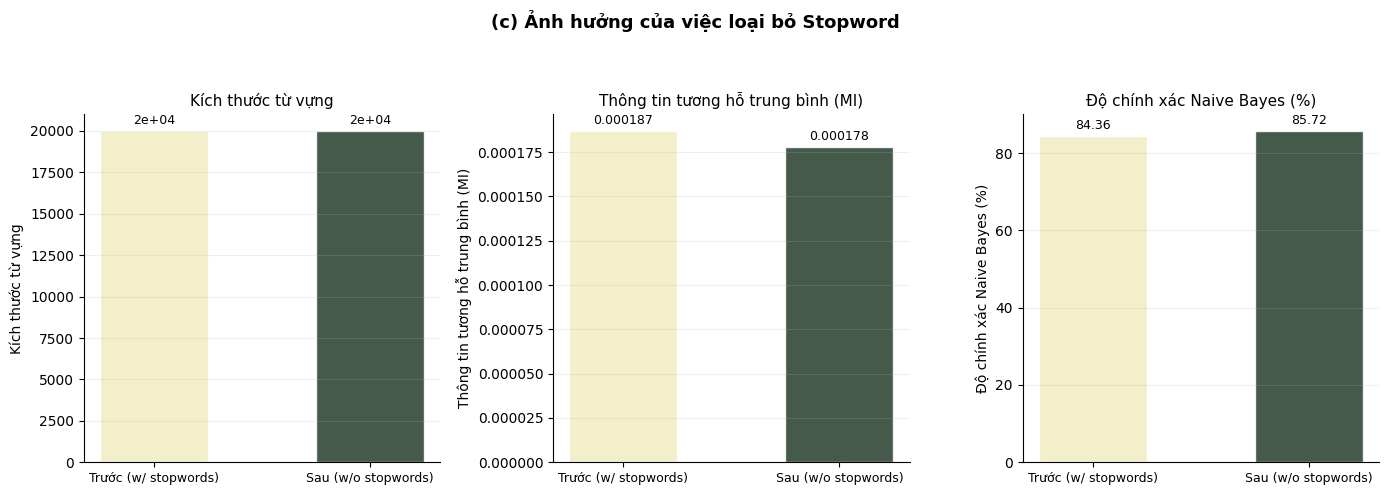

In [5]:
# c) STOPWORD REMOVAL + MUTUAL INFORMATION + NAIVE BAYES
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("c) STOPWORD REMOVAL + MI + NAIVE BAYES")
print("="*65)

STOP_EN = set(nltk_sw.words('english'))

df_full = df.copy()
df_full['text_norm'] = s6  


# ── Train/test split ─────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    df_full['text_norm'], df_full['label'], test_size=0.2, random_state=42, stratify=df_full['label']
)

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOP_EN)

X_tr_sw = X_tr.apply(remove_stopwords)
X_te_sw = X_te.apply(remove_stopwords)

results_sw = []

for suffix, x_train, x_test, tag in [
    ('Trước (w/ stopwords)', X_tr, X_te, 'before'),
    ('Sau (w/o stopwords)',  X_tr_sw, X_te_sw, 'after'),
]:
    vec = CountVectorizer(max_features=20000, min_df=2)
    X_tr_vec = vec.fit_transform(x_train)
    X_te_vec = vec.transform(x_test)

    # Vocab size
    v_size = len(vec.vocabulary_)

    # MI (trên train set, top 5000 features để nhanh)
    mi = mutual_info_classif(X_tr_vec, y_tr, discrete_features=True, random_state=42)
    avg_mi = mi.mean()

    # Naive Bayes accuracy (5-fold CV trên train)
    nb = MultinomialNB()
    cv_scores = cross_val_score(nb, X_tr_vec, y_tr, cv=5, scoring='accuracy')
    nb_acc_cv = cv_scores.mean()

    # NB test accuracy
    nb.fit(X_tr_vec, y_tr)
    nb_acc_test = accuracy_score(y_te, nb.predict(X_te_vec))

    results_sw.append({
        'Trạng thái': suffix,
        'Vocab size': v_size,
        'Avg MI': round(avg_mi, 6),
        'NB CV Acc (%)': round(nb_acc_cv*100, 2),
        'NB Test Acc (%)': round(nb_acc_test*100, 2),
    })
    print(f"  {suffix}: vocab={v_size:,}, avgMI={avg_mi:.6f}, "
          f"CV={nb_acc_cv*100:.2f}%, Test={nb_acc_test*100:.2f}%")

sw_df = pd.DataFrame(results_sw)
print("\n=== Bảng so sánh trước/sau loại stopwords ===")
print(sw_df.to_string(index=False))
sw_df.to_csv(f"{output_dir}/c_stopwords.csv", index=False)
print("Đã lưu: c_stopwords.csv")

# ── Visualize ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("(c) Ảnh hưởng của việc loại bỏ Stopword", fontsize=13, fontweight='bold')

pal = ['#F2EDC2', '#263d2d']

for ax, col, title in zip(
    axes,
    ['Vocab size', 'Avg MI', 'NB Test Acc (%)'],
    ['Kích thước từ vựng', 'Thông tin tương hỗ trung bình (MI)', 'Độ chính xác Naive Bayes (%)']
):
    bars = ax.bar(sw_df['Trạng thái'], sw_df[col],
                  color=pal, alpha=0.85, edgecolor='white', width=0.5)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(title)

    # hiển thị giá trị trên cột
    ax.bar_label(bars, fmt='%.4g', padding=3, fontsize=9)

    # fix label trục x
    ax.set_xticks(range(len(sw_df['Trạng thái'])))
    ax.set_xticklabels(sw_df['Trạng thái'], fontsize=9)

    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(f"{output_dir}/c_stopwords.png", dpi=300, bbox_inches='tight')
print("Đã lưu: c_stopwords.png")
plt.show()

### **🔥 Thảo luận**

**1. Kích thước từ vựng**
- Gần như **không thay đổi đáng kể** (~20k trước và sau).
- Điều này cho thấy stopwords không chiếm tỷ trọng lớn trong tập từ vựng (do đã bị lọc bởi `min_df`).

**2. Mutual Information (MI)**
- MI trung bình **giảm nhẹ** sau khi loại stopwords.
- Nguyên nhân: một số stopwords (như *not, no*) vẫn mang thông tin ngữ nghĩa quan trọng cho sentiment → loại bỏ có thể làm mất tín hiệu.

**3. Độ chính xác Naive Bayes**
- Accuracy **tăng nhẹ** (84.36% → 85.72%).
- Cho thấy việc loại bỏ stopwords giúp:
  - Giảm nhiễu
  - Làm mô hình tập trung vào từ mang ý nghĩa chính

---

### **✅ Kết luận**

- Stopword removal **không phải lúc nào cũng cải thiện mọi metric**:
  - Giảm nhẹ MI (mất thông tin cục bộ)
  - Tăng accuracy (giảm nhiễu tổng thể)

- Hiệu quả phụ thuộc vào:
  - Bài toán (sentiment vs topic classification)
  - Mô hình sử dụng (NB nhạy với nhiễu từ phổ biến)

## **📌 d) Stemming, Lemmatization và so sánh định lượng**

---

### **🎯 Mục tiêu**

Mục tiêu của phần này:
- 🔄 So sánh các phương pháp chuẩn hóa từ: Stemming và Lemmatization  
- 📉 Đánh giá mức độ giảm kích thước từ vựng thông qua **Collision Rate**  
- 🤖 Phân tích ảnh hưởng đến hiệu năng phân loại (Logistic Regression)  

---

### **⚙️ Phương pháp**

Thực nghiệm được thực hiện trên tập con dữ liệu đã chuẩn hóa (`text_norm`):

Các phương pháp được so sánh:

#### **🔹 1. Porter Stemmer**
- Cắt bỏ hậu tố theo quy tắc thủ công  

#### **🔹 2. Snowball Stemmer**
- Phiên bản cải tiến của Porter  

#### **🔹 3. WordNet Lemmatizer**
- Dựa trên từ điển (WordNet)  
---

### **📏 Chỉ số đánh giá**

#### **🔤 Collision Rate**

Đo mức độ các từ khác nhau bị ánh xạ về cùng một dạng:

$$
\text{Collision Rate} = \frac{V_{orig} - V_{proc}}{V_{orig}}
$$

Trong đó:
- $V_{orig}$: số lượng từ khác nhau ban đầu  
- $V_{proc}$: số lượng từ sau khi xử lý  

📌 Ý nghĩa:
- Cao → giảm vocab mạnh (có thể mất thông tin)  
- Thấp → giữ được nhiều thông tin hơn  

---

#### **🤖 Classification Accuracy (Logistic Regression)**

- Sử dụng Bag-of-Words (CountVectorizer)  
- Đánh giá bằng **5-fold Cross Validation**

📌 Mục tiêu:
- Kiểm tra ảnh hưởng của mỗi phương pháp đến khả năng phân loại  

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



d) STEMMING, LEMMATIZATION & COLLISION RATE
Baseline   | Collision: 0.0000 | CV Acc: 84.90%
Porter     | Collision: 0.1084 | CV Acc: 84.04%
Snowball   | Collision: 0.1495 | CV Acc: 84.16%
Lemma      | Collision: 0.0794 | CV Acc: 84.18%

=== Bảng kết quả ===
Phương pháp  Collision rate  CV Accuracy (%)
   Baseline          0.0000            84.90
     Porter          0.1084            84.04
   Snowball          0.1495            84.16
      Lemma          0.0794            84.18
Đã lưu: d_stemming_results.csv
Đã lưu: d_stemming_comparison.png


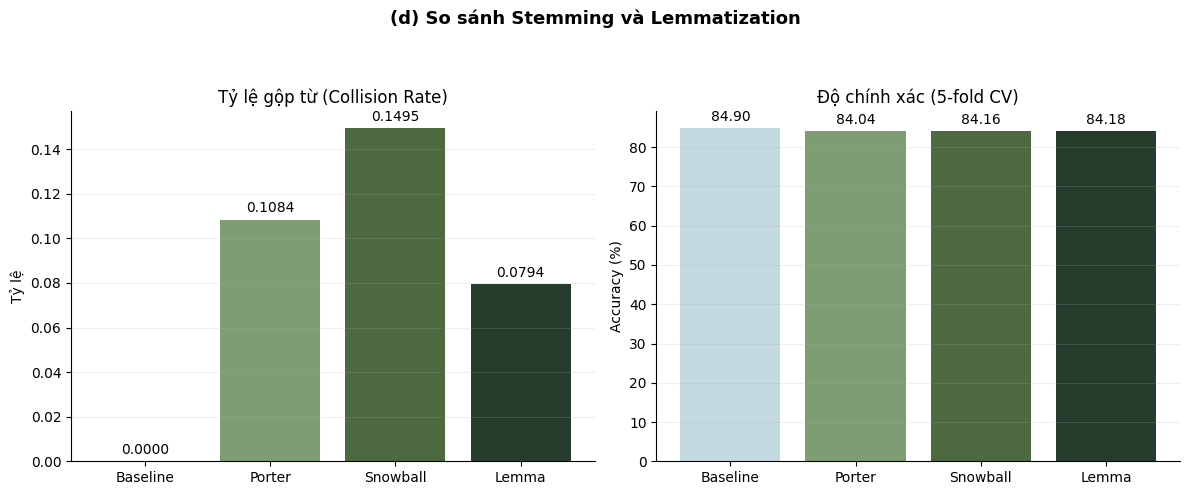

In [6]:
# d) STEMMING, LEMMATIZATION & COLLISION RATE
# ════════════════════════════════════════════════════════════════════
from collections import defaultdict

from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import pos_tag
import nltk

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# ── Download resources ──────────────────────────────────────────────
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')


# ── Mapping POS cho WordNet ─────────────────────────────────────────
def get_wordnet_pos(tag):
    if tag.startswith('J'): return 'a'
    if tag.startswith('V'): return 'v'
    if tag.startswith('N'): return 'n'
    if tag.startswith('R'): return 'r'
    return 'n'


# ── Tính collision rate (FIXED) ────────────────────────────────────
def compute_collision(orig_token_lists, proc_token_lists):
    """
    orig_token_lists : list of lists — token gốc theo từng câu
    proc_token_lists : list of lists — token sau xử lý theo từng câu
    Zip theo từng câu → đảm bảo đúng cặp (từ gốc, từ đã xử lý)
    """
    stem_to_words = defaultdict(set)

    for orig_words, proc_words in zip(orig_token_lists, proc_token_lists):
        for o, p in zip(orig_words, proc_words):
            stem_to_words[p].add(o)

    if len(stem_to_words) == 0:
        return 0.0

    # Collision: gốc p tương ứng với nhiều hơn 1 từ gốc o
    collisions = sum(len(v) > 1 for v in stem_to_words.values())
    return collisions / len(stem_to_words)


# ── Hàm chính ───────────────────────────────────────────────────────
def evaluate_stemming_lemmatization(df, sample_size=5000, output_dir="../data/images/preprocessing_text"):

    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "="*65)
    print("d) STEMMING, LEMMATIZATION & COLLISION RATE")
    print("="*65)

    # ── Sample ───────────────────────────────────────────────
    subset = df.sample(sample_size, random_state=42)

    # ── Token gốc dạng list of lists ─────────────────────────
    token_lists = subset['text_norm'].str.split()          # Series of lists
    orig_token_lists = token_lists.tolist()                # list of lists

    # ── Methods ──────────────────────────────────────────────
    methods = {
        'Baseline': None,
        'Porter'  : PorterStemmer(),
        'Snowball': SnowballStemmer('english'),
        'Lemma'   : WordNetLemmatizer()
    }

    results = []

    # ── Loop ─────────────────────────────────────────────────
    for name, tool in methods.items():

        # ---- Transform → proc_token_lists (list of lists) ----
        if name == 'Baseline':
            proc_token_lists = orig_token_lists  # không đổi gì

        elif name == 'Lemma':
            proc_token_lists = [
                [tool.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(words)]
                for words in orig_token_lists
            ]

        else:  # Porter / Snowball
            proc_token_lists = [
                [tool.stem(w) for w in words]
                for words in orig_token_lists
            ]

        # ---- Collision rate (FIXED: zip theo từng câu) ----
        collision_rate = compute_collision(orig_token_lists, proc_token_lists)

        # ---- Vector hóa ----
        texts = [' '.join(words) for words in proc_token_lists]

        vec = CountVectorizer(max_features=5000, min_df=2)
        X   = vec.fit_transform(texts)

        # ---- Logistic Regression + 5-fold CV ----
        model  = LogisticRegression(max_iter=1000, solver='liblinear')
        scores = cross_val_score(model, X, subset['label'], cv=5, scoring='accuracy')

        # ---- Lưu ----
        results.append({
            'Phương pháp'   : name,
            'Collision rate': round(collision_rate, 4),
            'CV Accuracy (%)': round(scores.mean() * 100, 2)
        })

        print(f"{name:<10} | Collision: {collision_rate:.4f} | CV Acc: {scores.mean()*100:.2f}%")

    # ── DataFrame ─────────────────────────────────────────────
    res_df = pd.DataFrame(results)

    print("\n=== Bảng kết quả ===")
    print(res_df.to_string(index=False))

    # ── Lưu CSV ───────────────────────────────────────────────
    res_df.to_csv(f"{output_dir}/d_stemming_results.csv", index=False)
    print("Đã lưu: d_stemming_results.csv")

    # ── Visualization ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("(d) So sánh Stemming và Lemmatization", fontsize=13, fontweight='bold')

    # Collision
    ax0  = axes[0]
    bars0 = ax0.bar(res_df['Phương pháp'], res_df['Collision rate'],
                    color=['#c3dae0','#7e9d73','#4d6940','#263d2d'])
    ax0.set_title('Tỷ lệ gộp từ (Collision Rate)')
    ax0.set_ylabel('Tỷ lệ')
    ax0.bar_label(bars0, padding=3, fmt='%.4f')

    # Accuracy
    ax1  = axes[1]
    bars1 = ax1.bar(res_df['Phương pháp'], res_df['CV Accuracy (%)'],
                    color=['#c3dae0','#7e9d73','#4d6940','#263d2d'])
    ax1.set_title('Độ chính xác (5-fold CV)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.bar_label(bars1, padding=3, fmt='%.2f')

    for ax in axes:
        ax.grid(axis='y', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # ── Save hình ─────────────────────────────────────────────
    plt.savefig(f"{output_dir}/d_stemming_comparison.png", dpi=300, bbox_inches='tight')
    print("Đã lưu: d_stemming_comparison.png")

    plt.show()

    return res_df

# ── Run ───────────────────────────────────────────────────────
res_df = evaluate_stemming_lemmatization(df)

### **📊 Đánh giá Stemming & Lemmatization**

**Nhận xét:**

* Baseline đạt accuracy cao nhất → giữ nguyên từ là tốt nhất
* Stemming (Porter, Snowball) làm giảm accuracy do collision cao
* Lemmatization tốt hơn stemming nhưng vẫn kém baseline
* Collision ↑ → Accuracy ↓

**Kết luận:**
- Stemming/Lemmatization không cải thiện mô hình trong bài toán sentiment


## **📌 e) Vector hóa văn bản và phân tích không gian đặc trưng**

---

### **🎯 Mục tiêu**

- 🔢 Chuyển văn bản thành dạng vector  
- 📊 Phân tích không gian đặc trưng  
- 🔍 Đánh giá khả năng tách lớp của dữ liệu  

---

### **⚙️ Phương pháp**

#### **🔹 1. TF-IDF (n-gram 1–3)**

- Sử dụng:
  - Unigram, Bigram, Trigram  
- Giới hạn:
  - `max_features = 5000`  

📌 Ý nghĩa:
- Kết hợp thông tin tần suất và độ quan trọng của từ  

---

### **📏 Chỉ số đánh giá**

#### **🔢 Số chiều (Dimensionality)**

$$
\text{Dimension} = \text{số đặc trưng (features)}
$$

#### **📉 Độ thưa (Sparsity)**

$$
\text{Sparsity} = 1 - \frac{\text{số phần tử khác 0}}{\text{tổng số phần tử}}
$$

📌 Ý nghĩa:
- Cao → dữ liệu rất thưa (phổ biến trong NLP)  

#### **📐 Cosine Similarity**

Đo độ tương đồng giữa các văn bản:

$$
\cos(\theta) = \frac{A \cdot B}{||A|| \, ||B||}
$$

So sánh:
- 📌 **Intra-class** (cùng lớp)  
- 📌 **Inter-class** (khác lớp)  


#### **📊 t-SNE Visualization**

- Giảm chiều từ không gian cao xuống 2D  
- Trực quan hóa phân bố dữ liệu  

#### **📏 Silhouette Score**

Đánh giá chất lượng phân cụm:

$$
s = \frac{b - a}{\max(a, b)}
$$

Trong đó:
- $a$: khoảng cách nội cụm  
- $b$: khoảng cách liên cụm  

📌 Ý nghĩa:
- Gần 1 → phân cụm tốt  
- Gần 0 → chồng lấn  
- < 0 → phân cụm sai  


e) VECTOR HÓA & PHÂN TÍCH KHÔNG GIAN ĐẶC TRƯNG
Đã lưu biểu đồ: ../data/images/preprocessing_text/e_vectorization_comparison.png


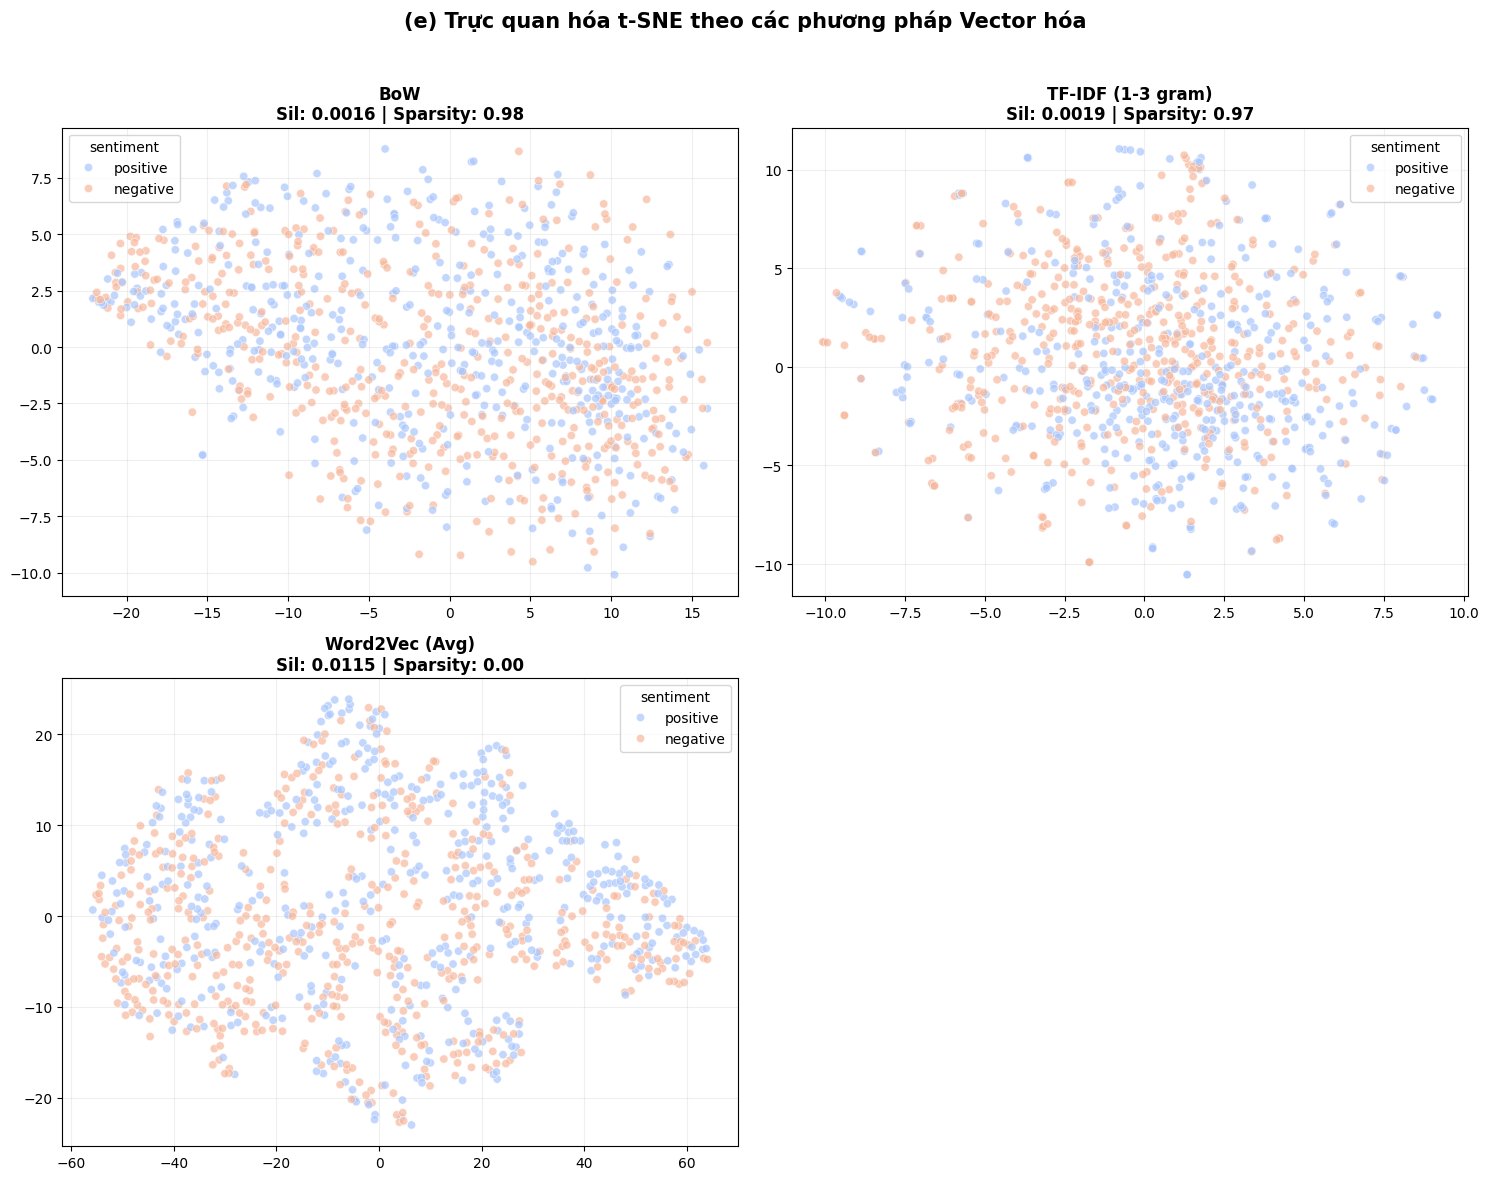

Đã lưu kết quả CSV: ../data/images/preprocessing_text/e_vectorization_comparison.csv

=== TỔNG KẾT KẾT QUẢ PHẦN E ===


,Method,Dimension,Sparsity,Intra-Sim,Inter-Sim,Silhouette
0,BoW,5000,0.9761,0.5343,0.5289,0.0016
1,TF-IDF (1-3 gram),5000,0.9663,0.1388,0.1353,0.0019
2,Word2Vec (Avg),100,0.0000,0.9981,0.9981,0.0115


In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

def analyze_feature_space(df, sample_size=1000, output_dir="../data/images/preprocessing_text"):
    """
    Phần 2.3.3 (e): BoW, TF-IDF và Word2Vec Visualization với bố cục 2x2
    """
    print("\n" + "="*65)
    print("e) VECTOR HÓA & PHÂN TÍCH KHÔNG GIAN ĐẶC TRƯNG")
    print("="*65)
    
    # Đảm bảo thư mục đầu ra tồn tại
    os.makedirs(output_dir, exist_ok=True)
    
    subset = df.sample(sample_size, random_state=42).reset_index(drop=True)
    labels = subset['label']
    texts = subset['text_norm']
    
    # --- 1. Cài đặt các bộ Vectorizer ---
    # BoW
    bow_vec = CountVectorizer(max_features=5000)
    # TF-IDF (ngram 1,2,3)
    tfidf_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
    
    # Word2Vec (Huấn luyện trên tập dữ liệu hiện có)
    tokenized_texts = [doc.split() for doc in texts]
    w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)
    
    def get_w2v_avg(tokens, model):
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

    # --- 2. Xử lý và đánh giá từng biểu diễn ---
    representations = {
        'BoW': bow_vec.fit_transform(texts),
        'TF-IDF (1-3 gram)': tfidf_vec.fit_transform(texts),
        'Word2Vec (Avg)': np.array([get_w2v_avg(t, w2v_model) for t in tokenized_texts])
    }
    
    summary_results = []
    
  
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("(e) Trực quan hóa t-SNE theo các phương pháp Vector hóa", fontsize=15, fontweight='bold')
    
    # Trải phẳng axes để truy cập index 0, 1, 2, 3
    axes_flat = axes.flatten()

    for i, (name, X) in enumerate(representations.items()):
       
        shape = X.shape
        if hasattr(X, "nnz"): # Dành cho sparse matrix (BoW, TF-IDF)
            sparsity = 1.0 - (X.nnz / (shape[0] * shape[1]))
        else:  
            sparsity = 0.0
            
        # (ii) Cosine Similarity
        cos_sim = cosine_similarity(X)
        pos_idx = np.where(labels == 1)[0]
        neg_idx = np.where(labels == 0)[0]
        
        intra_sim = np.mean(cos_sim[np.ix_(pos_idx, pos_idx)])
        inter_sim = np.mean(cos_sim[np.ix_(pos_idx, neg_idx)])
        
        # (iii) t-SNE & Silhouette Score
        tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
        X_dense = X.toarray() if hasattr(X, "toarray") else X
        X_2d = tsne.fit_transform(X_dense)
        sil = silhouette_score(X_dense, labels)
        
        # Vẽ biểu đồ vào ô tương ứng
        ax = axes_flat[i]
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=subset['sentiment'], ax=ax, palette='coolwarm', alpha=0.7)
        ax.set_title(f"{name}\nSil: {sil:.4f} | Sparsity: {sparsity:.2f}", fontsize=12, fontweight='semibold')
        ax.grid(True, alpha=0.2)
        
        summary_results.append({
            'Method': name, 
            'Dimension': shape[1], 
            'Sparsity': round(sparsity, 4),
            'Intra-Sim': round(intra_sim, 4), 
            'Inter-Sim': round(inter_sim, 4), 
            'Silhouette': round(sil, 4)
        })

    # --- 3. Để trống ô số 4 ---
    axes_flat[3].axis('off') 

    # Lưu và hiển thị hình ảnh
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plot_path = f"{output_dir}/e_vectorization_comparison.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ: {plot_path}")
    plt.show()
    
    return pd.DataFrame(summary_results)

# --- THỰC THI ---
results_e = analyze_feature_space(df)

# Lưu kết quả bảng thống kê
csv_path = f"{output_dir}/e_vectorization_comparison.csv"
results_e.to_csv(csv_path, index=False)

print(f"Đã lưu kết quả CSV: {csv_path}")
print("\n=== TỔNG KẾT KẾT QUẢ PHẦN E ===")
display(results_e)

### **🔍 Kết quả**

| Phương pháp | Silhouette | Sparsity |
|------------|------------|----------|
| BoW | 0.0016 | 0.98 |
| TF-IDF | 0.0019 | 0.97 |
| Word2Vec | 0.0116 | 0.00 |

---

### **📏 Nhận xét**

- Tất cả Silhouette Score ≈ 0 → Dữ liệu **không tách lớp rõ ràng**

- **BoW, TF-IDF**:
  - Vector sparse  
  - Không hiểu ngữ nghĩa  
  → tách lớp kém  

- **Word2Vec**:
  - Dense, có ngữ nghĩa hơn  
  → tốt hơn nhưng vẫn thấp  

---

### **🎯 Kết luận**

> Các phương pháp vector hóa hiện tại chưa đủ khả năng phân biệt sentiment. Cần sử dụng embedding mạnh hơn như Sentence Transformer để cải thiện khả năng tách lớp.

## **📌 f) Biểu diễn ngữ nghĩa bằng Sentence Transformer**

---

### **🎯 Mục tiêu**

- 🧠 Biểu diễn văn bản theo ngữ nghĩa (semantic embedding)  
- ⚖️ So sánh với TF-IDF  
- 📊 Đánh giá phân cụm và phân loại  

---

### **⚙️ Phương pháp**

#### **🔹 1. Sentence Transformer**

- Sử dụng mô hình pretrained:
  - `all-MiniLM-L6-v2`  
- Biểu diễn câu dưới dạng vector dense  
- Hiểu ngữ nghĩa và ngữ cảnh  


#### **🔹 2. K-Means Clustering**

- Phân cụm dữ liệu thành 2 nhóm  
- Đánh giá bằng: Silhouette Score  


#### **🔹 3. Phân loại với Linear SVM**

- Sử dụng embedding làm input  
- Đánh giá bằng 5-fold CV  

---

### **📏 Chỉ số đánh giá**

#### **📊 Silhouette Score (Clustering)**

- Đánh giá mức độ tách biệt của các cụm  

#### **🤖 SVM Accuracy**

- Đo hiệu năng phân loại  


f) SO SÁNH BIỂU DIỄN NGỮ NGHĨA (ST vs TF-IDF)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

  Đang tính t-SNE cho TF-IDF...
  Đang tính t-SNE cho Sentence Transformer...


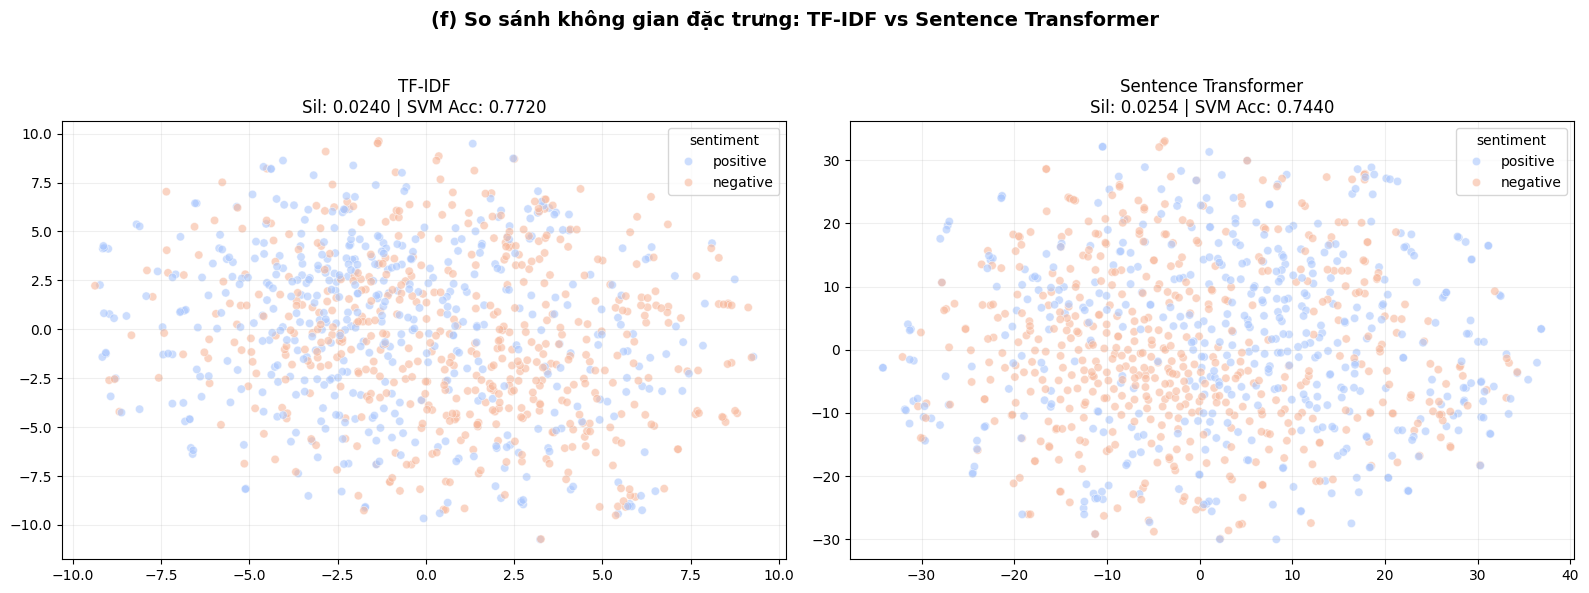


=== BẢNG SO SÁNH ĐỊNH LƯỢNG ===
              Method  Silhouette Score  SVM Accuracy
              TF-IDF            0.0240         0.772
Sentence Transformer            0.0254         0.744


In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC

def evaluate_semantic_comparison(df, sample_size=1000, output_dir="../data/images/preprocessing_text"):
    print("\n" + "="*65)
    print("f) SO SÁNH BIỂU DIỄN NGỮ NGHĨA (ST vs TF-IDF)")
    print("="*65)
    
    os.makedirs(output_dir, exist_ok=True)
    subset = df.sample(sample_size, random_state=42).reset_index(drop=True)
    texts = subset['text_norm'].tolist()
    labels = subset['label']
    sentiment_labels = subset['sentiment']

    # 1. Trích xuất đặc trưng
    tfidf_vec = TfidfVectorizer(max_features=384)
    X_tfidf = tfidf_vec.fit_transform(texts).toarray()

    model = SentenceTransformer('all-MiniLM-L6-v2')
    X_st = model.encode(texts, show_progress_bar=True)

    # 2. Đánh giá và Vẽ biểu đồ
    methods = {"TF-IDF": X_tfidf, "Sentence Transformer": X_st}
    final_results = []
    
    # Thiết kế biểu đồ 1 hàng 2 cột
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("(f) So sánh không gian đặc trưng: TF-IDF vs Sentence Transformer", fontsize=14, fontweight='bold')

    for i, (name, X) in enumerate(methods.items()):
        # --- Tính toán chỉ số ---
        kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
        clusters = kmeans.fit_predict(X)
        sil = silhouette_score(X, clusters)
        
        svc = LinearSVC(dual=False, max_iter=2000)
        acc = cross_val_score(svc, X, labels, cv=5).mean()
        
        final_results.append({
            "Method": name,
            "Silhouette Score": round(sil, 4),
            "SVM Accuracy": round(acc, 4)
        })

        # --- Trực quan hóa t-SNE ---
        print(f"  Đang tính t-SNE cho {name}...")
        tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
        X_2d = tsne.fit_transform(X)
        
        ax = axes[i]
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=sentiment_labels, ax=ax, palette='coolwarm', alpha=0.6)
        ax.set_title(f"{name}\nSil: {sil:.4f} | SVM Acc: {acc:.4f}", fontsize=12)
        ax.grid(True, alpha=0.2)

    # Lưu hình ảnh
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{output_dir}/f_semantic_comparison_viz.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Xuất bảng so sánh
    res_df = pd.DataFrame(final_results)
    print("\n=== BẢNG SO SÁNH ĐỊNH LƯỢNG ===")
    print(res_df.to_string(index=False))
    
    res_df.to_csv(f"{output_dir}/f_semantic_comparison.csv", index=False)
    
    return res_df

# Chạy thử nghiệm
results_f = evaluate_semantic_comparison(df)

### 🔍 Kết quả

| Method | Silhouette | SVM Accuracy |
|--------|------------|--------------|
| TF-IDF | 0.0240 | 0.772 |
| Sentence Transformer | 0.0254 | 0.744 |

---

### 🧠 Giải thích sự khác biệt về ngữ nghĩa

#### 🔤 **TF-IDF**
- Dựa trên **tần suất từ**  
- Không hiểu ngữ nghĩa  
- Hai câu khác từ → vector khác hoàn toàn  
- Ví dụ: "good movie" ≠ "great film"  

#### 🧠 **Sentence Transformer**
- Biểu diễn dựa trên **ngữ nghĩa và ngữ cảnh**  
- Các câu cùng ý nghĩa → vector gần nhau  
- Ví dụ: "good movie" ≈ "great film"  

---

### 📏 Phân tích kết quả

- Sentence Transformer:
  - Silhouette cao hơn → **tách cụm tốt hơn về mặt ngữ nghĩa**  
  - Accuracy thấp hơn → có thể do:
    - Dataset nhỏ  
    - Chưa fine-tune  

- TF-IDF:
  - Accuracy cao hơn → phù hợp với bài toán đơn giản  
  - Không hiểu ngữ nghĩa sâu  

---

### 🎯 Kết luận

> TF-IDF hoạt động tốt với bài toán phân loại dựa trên từ khóa, trong khi Sentence Transformer biểu diễn tốt hơn về mặt ngữ nghĩa. Tuy nhiên, để tận dụng hết sức mạnh của Sentence Transformer, cần dữ liệu lớn hoặc fine-tuning.